# Pre-RA Flow PM1: Cell type level subclustering

Scaling, dimension reduction, UMAP, freq stats

## Setup

In [1]:
%config Completer.use_jedi = False
import scyan as sy
import os
import glob
import anndata
import re
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import scanpy.external as sce
import copy
from concurrent.futures import ProcessPoolExecutor

print(sy.__version__)
print(anndata.__version__)


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


1.5.1
0.10.6


In [55]:
#### ==== parameter set up ==== ####
# define the working path
panel = "PM1"
# define l1 cell types to subset
cell_types = ["total_myeloid_cells"]
# define markers used for clustering
antigens = ["CD14","CD192 (CCR2)", "CD195 (CCR5)", "CD197 (CCR7)", "CD40", "CD86", "CD80","CD1c","CD370 (CLEC9A)","CD172a (SIRPa)","CD11b","CD11c","CD123","CD141","CD15","CD16","CD274 (PD-L1)","CD304" ,"CD33","CX3CR1"]
data_path='/home/jupyter/projects/pre-ra/flow/raw-data/' + panel + '/labelled-expr/cache/'
fig_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/results/' + panel + '_celltype_subsample'  + "/"
proj_name = 'pre-ra_flow_clustering_' + panel
output_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/data/' +panel + '/'

if not os.path.exists(fig_path): os.makedirs(fig_path)
    
if not os.path.exists(output_path): os.makedirs(output_path)

# define scanpy verbose levels
sc.settings.verbosity = 3
sc.settings.figdir = fig_path
sc.settings.n_jobs = 30

## Functions

In [4]:
def read_anndata_files(file_tuples):
    """
    Read Anndata objects from H5AD files and store them in a dictionary with custom names.

    Parameters:
        file_tuples (list of tuples): List of tuples where each tuple contains filename and desired name.

    Returns:
        dict: Dictionary containing Anndata objects with custom names.
    """
    anndata_dict = {}
    for filename, name in file_tuples:
        anndata_obj = anndata.read_h5ad(filename)
        anndata_dict[name] = anndata_obj
    return anndata_dict

In [5]:
def save_anndata_list(anndata_list, filenames):
    """
    Save a list of Anndata objects to separate H5AD files.

    Parameters:
        anndata_list (list): List of Anndata objects to be saved.
        filenames (list): List of filenames to save Anndata objects.

    Returns:
        None
    """
    # zip() combines two lists into a single tuple
    for anndata_obj, filename in zip(adata_downsampled_celltypes, filenames):
        print(adata_downsampled_celltypes[anndata_obj])
        adata_downsampled_celltypes[anndata_obj].write_h5ad(filename)

In [6]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))

In [51]:
def leiden_new(

    adata,

    resolution: float = 1,

    key_added: str = "leiden",

    n_neighbors: int = 15,

) -> None:

    """Leiden clustering
 
    Args:

        adata: AnnData object.

        resolution: Resolution of the clustering.

        key_added: Name of the key of adata.obs where clusters will be saved.

        n_neighbors: Number of neighbors.

    """

    try:

        import leidenalg

    except:

        raise ImportError(

            """To run leiden, you need to have 'leidenalg' installed. You can install the population discovery extra with "pip install 'scyan[discovery]'", or directly install leidenalg with "conda install -c conda-forge leidenalg"."""

        )
 
    import igraph as ig

    from sklearn.neighbors import kneighbors_graph
 
    if not "knn_graph" in adata.obsp:

        adata.obsp["knn_graph"] = kneighbors_graph(

            adata.obsm['X_pca_harmony'][:,0:10], n_neighbors=n_neighbors, metric="euclidean", include_self=False

        )
 
    # TODO (improvement): add weights according to euclidean distance

    graph = ig.Graph.Weighted_Adjacency(adata.obsp["knn_graph"], mode="DIRECTED")
 
    partition = leidenalg.find_partition(

        graph,

        leidenalg.RBConfigurationVertexPartition,

        resolution_parameter=resolution,

    )

    adata.obs[key_added] = pd.Categorical([str(x) for x in partition.membership])
 
def run_leiden(adata, resolution, key_added):

    # Make a copy of adata for thread safety

    adata_copy = copy.deepcopy(adata)

    leiden_new(adata_copy, resolution=resolution, key_added=key_added)

    return adata_copy.obs

def run_leiden_parallel(adata, tasks):

    with ProcessPoolExecutor(max_workers=5) as executor:

        # Make deep copies of adata for each task to ensure thread safety

        futures = [executor.submit(run_leiden, copy.deepcopy(adata), resolution, key_added) for resolution, key_added in tasks]

        results = [future.result() for future in futures]

    # Assign the results back to the original AnnData object

    for result, (_, key_added) in zip(results, tasks):

        adata.obs[key_added] = result[key_added]

    return adata

## Read in data

In [7]:
filenames = get_filepaths_with_glob(output_path, "adata_preprocess_unscaled_downsmpl_celltypes_*.h5ad")  
filenames

['/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_preprocess_unscaled_downsmpl_celltypes_total_myeloid_cells_PM1.h5ad']

In [9]:
# Extract the cell types between "celltypes_" and "PT1.h5ad"
cell_types = [path.split('celltypes_')[1].split('_' +panel+'.h5ad')[0] for path in filenames]
cell_types

['total_myeloid_cells']

In [10]:
## turn filenames and cell types into tuple
file_tups = list(zip(filenames, cell_types))
file_tups

[('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_preprocess_unscaled_downsmpl_celltypes_total_myeloid_cells_PM1.h5ad',
  'total_myeloid_cells')]

In [11]:
adata_downsampled_celltypes = read_anndata_files(file_tups)
adata_downsampled_celltypes

{'total_myeloid_cells': AnnData object with n_obs × n_vars = 4192099 × 25
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'}

In [12]:
## read in panel df
panel_df = pd.read_csv('/home/jupyter/projects/pre-ra/flow/raw-data/AIFI_flow_' + panel + '_panel_breakdown.csv')
panel_df.tail()

,fcs_colname,antigen,range,minRange,maxRange,marker_class,chn_type,backbone_markers,used_for_clustering
31,Comp-PE-Cy5-A,CD16,4194304,-111.000351,4193244.25,type,fluorchnls,False,Yes
32,Comp-PE-Cy7-A,CD197 (CCR7),4194304,-111.000351,4193244.25,state,fluorchnls,False,No
33,Comp-APC-A,CD274 (PD-L1),4194304,-111.000351,4193244.25,state,fluorchnls,False,No
34,Comp-APC-R700-A,CD195 (CCR5),4194304,-111.000351,4193244.25,state,fluorchnls,False,No
35,Comp-APC-Cy7-A,CD1c,4194304,-111.000351,4193244.25,type,fluorchnls,False,Yes


## Specify highly var markers for clustering

In [21]:
## validate that clustering antigen markers present in panel df
gating_antigens = panel_df.loc[panel_df['used_for_clustering']=='Yes', 'antigen']

gating_antigens[~gating_antigens.isin(antigens)]

13      CD56
18    HLA-DR
Name: antigen, dtype: object

In [22]:
clust_antigens = [s + '_logicle' for s in antigens]
clust_antigens

['CD14_logicle',
 'CD192 (CCR2)_logicle',
 'CD195 (CCR5)_logicle',
 'CD197 (CCR7)_logicle',
 'CD40_logicle',
 'CD86_logicle',
 'CD80_logicle',
 'CD1c_logicle',
 'CD370 (CLEC9A)_logicle',
 'CD172a (SIRPa)_logicle',
 'CD11b_logicle',
 'CD11c_logicle',
 'CD123_logicle',
 'CD141_logicle',
 'CD15_logicle',
 'CD16_logicle',
 'CD274 (PD-L1)_logicle',
 'CD304_logicle',
 'CD33_logicle',
 'CX3CR1_logicle']

In [24]:
for label, sub_adata in adata_downsampled_celltypes.items():
    print("Key:", label)
    print("Value:", sub_adata)
    
    sub_adata.var['antigens'] = sub_adata.var.index.str.replace('_logicle', '')

    sub_adata.var[['gating_antigens']] = False
    sub_adata.var.loc[sub_adata.var.index.isin(clust_antigens),'gating_antigens'] = True
    sub_adata.var[['highly_variable']] = sub_adata.var[['gating_antigens']]
    print(sub_adata.var)
    
    adata_downsampled_celltypes[label] = sub_adata
    

Key: total_myeloid_cells
Value: AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
                              antigens  gating_antigens  highly_variable
CD14_logicle                      CD14             True             True
CD45_logicle                      CD45            False            False
CD15_logicle                      CD15             True             True
CD56_logicle         

In [25]:
adata_downsampled_celltypes

{'total_myeloid_cells': AnnData object with n_obs × n_vars = 4192099 × 25
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
     var: 'antigens', 'gating_antigens', 'highly_variable'
     uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca', 'neighbors'
     obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
     varm: 'PCs'
     obsp: 'distances', 'connectivities'}

In [18]:
adata_downsampled_celltypes[cell_types[0]].X

array([[1.1980926, 3.8813422, 1.2269175, ..., 1.2449279, 1.3383718,
        1.5575504],
       [1.4052787, 3.6007454, 1.9317755, ..., 1.1847236, 1.2224002,
        1.1983415],
       [3.3663194, 3.637114 , 1.3163167, ..., 1.1636224, 1.441974 ,
        1.4244721],
       ...,
       [3.7832975, 3.7660298, 2.456493 , ..., 1.0474113, 1.7767222,
        1.1242594],
       [1.3220259, 3.4931498, 1.2158314, ..., 0.9013457, 1.7785431,
        1.4230425],
       [2.3641634, 4.014984 , 1.5935642, ..., 1.7574633, 1.2451674,
        1.416803 ]], dtype=float32)

## Scale, PCA, Harmonize, UMAP

Key: total_myeloid_cells
Value: AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


[INFO] (scyan.preprocess) Data will be centered and standardised. This is advised only when using spectral/flow data (if this is not your case, consider running 'asinh_transform' instead of 'auto_logicle_transform').


computing PCA
    on highly variable genes
    with n_comps=19
    finished (0:00:04)


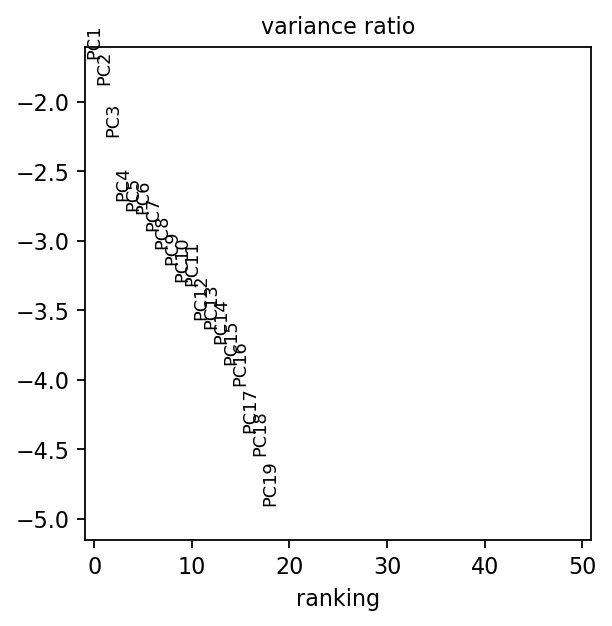

2024-04-12 04:28:31,711 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-04-12 08:28:39,248 - harmonypy - INFO - Iteration 6 of 10
2024-04-12 08:58:05,357 - harmonypy - INFO - Iteration 7 of 10


In [ ]:
%%time
for label, sub_adata in adata_downsampled_celltypes.items():
    print("Key:", label)
    print("Value:", sub_adata)
    
    sy.preprocess.scale(sub_adata)
    # stored in .var['highly_variable']
    sc.pp.pca(sub_adata, svd_solver="arpack", use_highly_variable=True)
    sc.pl.pca_variance_ratio(sub_adata, log=True, n_pcs=50, save='pca_var_' +label+'.png') # scanpy generates the filename automatically
    
    # perform batch correction
    sce.pp.harmony_integrate(sub_adata, 'batch', adjusted_basis='X_pca_harmony')
    
    # replace new pca slot
    sub_adata.obsm['X_pca'] = sub_adata.obsm['X_pca_harmony']

    # Perform re-clustering on the subset
    sc.pp.neighbors(sub_adata, n_neighbors=20, use_rep='X_pca_harmony')
    
    # skip leiden until parallelization
    
    sy.tools.umap(sub_adata, obsm='X_pca_harmony',markers=clust_antigens)
    
    
    p1=sy.plot.umap(sub_adata, color=['l1_labels','labels', 'batch','panel'], ncols =2, return_fig = True)
    p1.savefig(fig_path + label + "_umap_labels_batch_panel_" +panel + ".png",
               dpi=400, bbox_inches='tight')
    
    marker_umap  = sc.pl.umap(sub_adata, color=sub_adata.var_names.sort_values(),ncols=6, show=True, return_fig=True, size=.5)
    marker_umap.set_size_inches(18.5, 18.5)
    marker_umap.savefig(fig_path + label + "_umap_expression_labels_corrected_panel_" +panel + ".png")

    # store back to dict
    adata_downsampled_celltypes[label] = sub_adata
    
    

In [28]:
adata_downsampled_celltypes

{'total_myeloid_cells': AnnData object with n_obs × n_vars = 4192099 × 25
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
     var: 'antigens', 'gating_antigens', 'highly_variable'
     uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca', 'neighbors'
     obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
     varm: 'PCs'
     obsp: 'distances', 'connectivities'}

## Save

In [29]:
filenames = [output_path + "adata_scaled_harmonized_umap_downsmpl_celltypes_" + cell_type + "_" + panel + ".h5ad" for cell_type in cell_types]
filenames

['/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_scaled_harmonized_umap_downsmpl_celltypes_total_myeloid_cells_PM1.h5ad']

In [30]:
save_anndata_list(adata_downsampled_celltypes, filenames)

AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## Addt. UMAPs

Key: total_myeloid_cells
Value: AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'scyan_scaling_stds', 'scyan_scaling_means', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:885: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:885: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


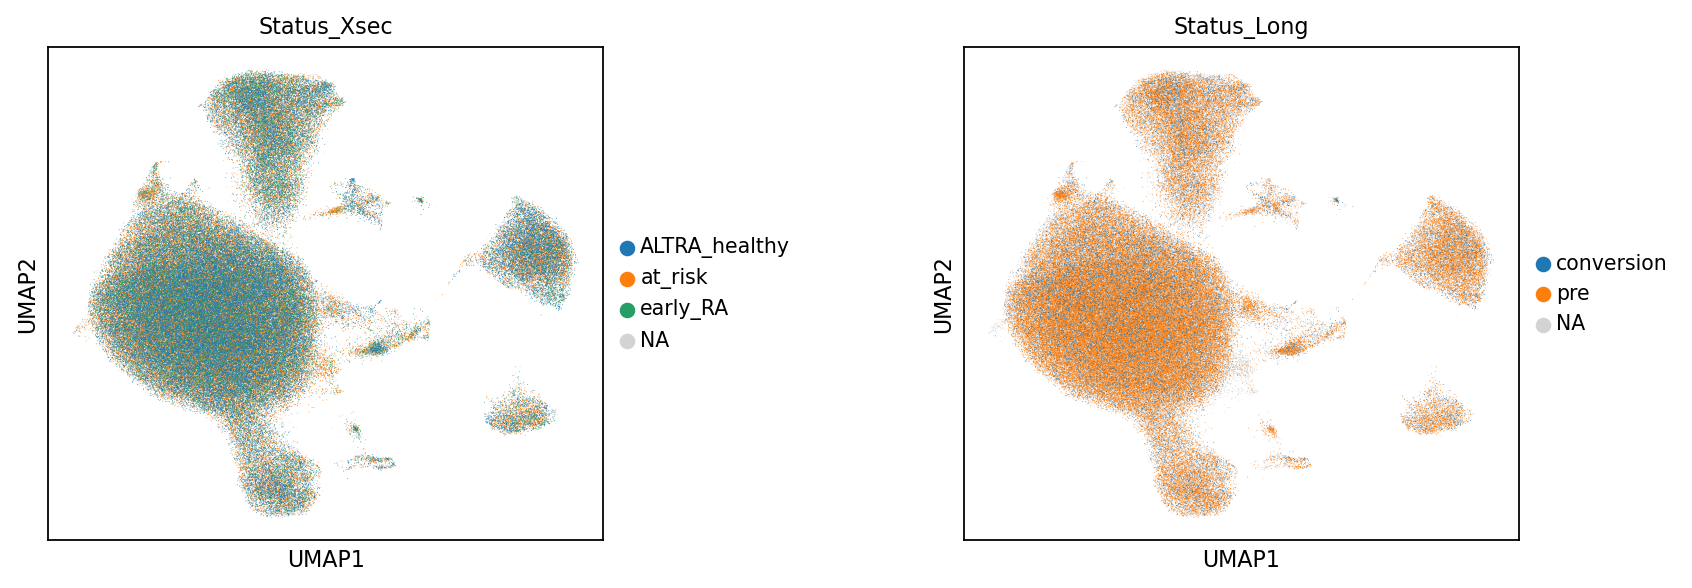

CPU times: user 4.5 s, sys: 196 ms, total: 4.7 s
Wall time: 4.31 s


In [41]:
%%time
for label, sub_adata in adata_downsampled_celltypes.items():
    print("Key:", label)
    print("Value:", sub_adata)
    p1=sy.plot.umap(sub_adata, color=['Status_Xsec', 'Status_Long'], ncols =2, return_fig = True,  wspace=.5)
    p1.savefig(fig_path + label + "_umap_status_" +panel + ".png", dpi=400, bbox_inches='tight')
    
    

## Leiden Parallization

In [ ]:
leiden_fig_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/results/' + proj_name + "/" + panel + "_leiden/"
print(leiden_fig_path)
if not os.path.exists(leiden_fig_path): os.makedirs(leiden_fig_path)


In [ ]:
%%time
for label, sub_adata in adata_downsampled_celltypes.items():
    print("Key:", label)
    print("Value:", sub_adata)
    
    tasks = [(2, "leiden_res_2"),(2.5, "leiden_res_2.5"),(3, "leiden_res_3")]
    leiden_res = ["leiden_res_2", "leiden_res_2.5",  "leiden_res_3"]

    sub_adata = run_leiden_parallel(sub_adata, tasks)

    print('leiden clustering completed...')
    
    p1 = sy.plot.umap(sub_adata, color= leiden_res ,return_fig = True, size = .5, ncols = 3,legend_loc="on data")
    p1.savefig(leiden_fig_path + label   + "_umap_leiden_resolutions_" + panel + ".png",  dpi=400, bbox_inches='tight')
    
    for res in leiden_res: 
        p1 = sy.plot.umap(sub_adata, color= res ,return_fig = True, size = .5)
        p1.savefig(leiden_fig_path + label   + "_umap_" + res + "_" +panel + ".png",dpi=400, bbox_inches='tight')
            
    # store back to dict
    adata_downsampled_celltypes[label] = sub_adata
    

In [46]:
fig_path + label   + "_umap_leiden_resolutions_" + panel + ".png"

'/home/jupyter/projects/pre-ra/flow/02-clustering/results/PM1_celltype_subsample/total_myeloid_cells_umap_leiden_resolutions_PM1.png'

## Leiden Custom (Speed up)

In [ ]:
filenames = get_filepaths_with_glob(output_path, "adata_leiden_scaled_harmonized_umap_downsmpl_celltypes_*.h5ad")  
print(filenames)

In [ ]:
# Extract the cell types between "celltypes_" and "PT1.h5ad"
cell_types = [path.split('celltypes_')[1].split('_' +panel+'.h5ad')[0] for path in filenames]
print(cell_types)

In [ ]:
## turn filenames and cell types into tuple
file_tups = list(zip(filenames, cell_types))
print(file_tups)

In [ ]:
adata_downsampled_celltypes = read_anndata_files(file_tups)
print(adata_downsampled_celltypes)

In [ ]:
# create separate leiden folder
leiden_fig_path = fig_path +  "/" + panel + "_leiden/"
print(leiden_fig_path)
if not os.path.exists(leiden_fig_path): os.makedirs(leiden_fig_path)



In [ ]:
keys_to_subset = cell_types

In [ ]:
subset_data = {key: value for key, value in adata_downsampled_celltypes.items() if key in keys_to_subset}
print(subset_data)

In [ ]:
for label, sub_adata in subset_data.items():
    print("Key:", label)
    print("Value:", sub_adata)
    
    tasks = [(1.0, "leiden_res_1.0")]
    leiden_res = [ "leiden_res_1.0"]

    sub_adata = run_leiden_parallel(sub_adata, tasks)

    print('leiden clustering completed...')
    
    p1 = sy.plot.umap(sub_adata, color= leiden_res ,return_fig = True, size = .5, ncols = 3,legend_loc="on data")
    p1.savefig(leiden_fig_path + label   + "_umap_leiden_resolutions_" + panel + ".png",  dpi=400, bbox_inches='tight')
    
    for res in leiden_res: 
        p1 = sy.plot.umap(sub_adata, color= res ,return_fig = True, size = .5)
        p1.savefig(leiden_fig_path + label   + "_umap_" + res + "_" +panel + ".png",dpi=400, bbox_inches='tight')
            
    # store back to dict
    adata_downsampled_celltypes[label] = sub_adata
    
    sub_adata.write_h5ad(output_path + "adata_" + leiden_res[0] + "_scaled_harmonized_umap_downsmpl_celltypes_" + label + "_" + panel + ".h5ad")
    